"""  
아래 내용이 필수적으로 들어가야 합니다.

- 회귀와 분류의 차이에 대해 설명해주세요.
- 분류 모델의 네 가지 종류와, 각 모델이 무엇인지 간단하게 정리해주세요.
- 분류 평가 지표에는 무엇이 있는지 작성해주세요.
- 하이퍼파라미터 최적화가 무엇인지 쓰세요.  

"""

# **분류란?**
## 회귀 VS 분류
| 구분 | 회귀 | 분류 |
|------|------|------|
| 대상 | 연속형 | 범주형 |
| 목적 | 회귀선을 찾아 수치 예측 | 레이블 판별 |
- 분류에 쓰이는 머신러닝 알고리즘: 로지스틱 회귀, 결정트리, 서포트 벡터 머신, 최소 근접 알고리즘

## 이진 분류 VS 다중 분류
- 이진 분류: 판별하고자 하는 레이블이 두 개 -> 참/거짓
- 다중 분류: 판별하고자 하는 레이블이 세 개 이상
---

# **분류 모델**
## 로지스틱 회귀
샘플이 특정 클래스에 **속할 확률을 추정**해 기준치에 따라 분류. 일반적인 선형 회귀와 달리 **이진 분류 문제**에 적합
> ### 기준치는 어떻게 정할까?
독립변수의 선형 조합(선형 회귀)에 로지스틱 함수 적용 -> 출력값을 0~1 사이의 확률값으로 변환 -> 기준값(보통 0.5)에 따라 클래스 분류
> ### 왜 일반적인 선형 회귀를 적용하지 않을까?
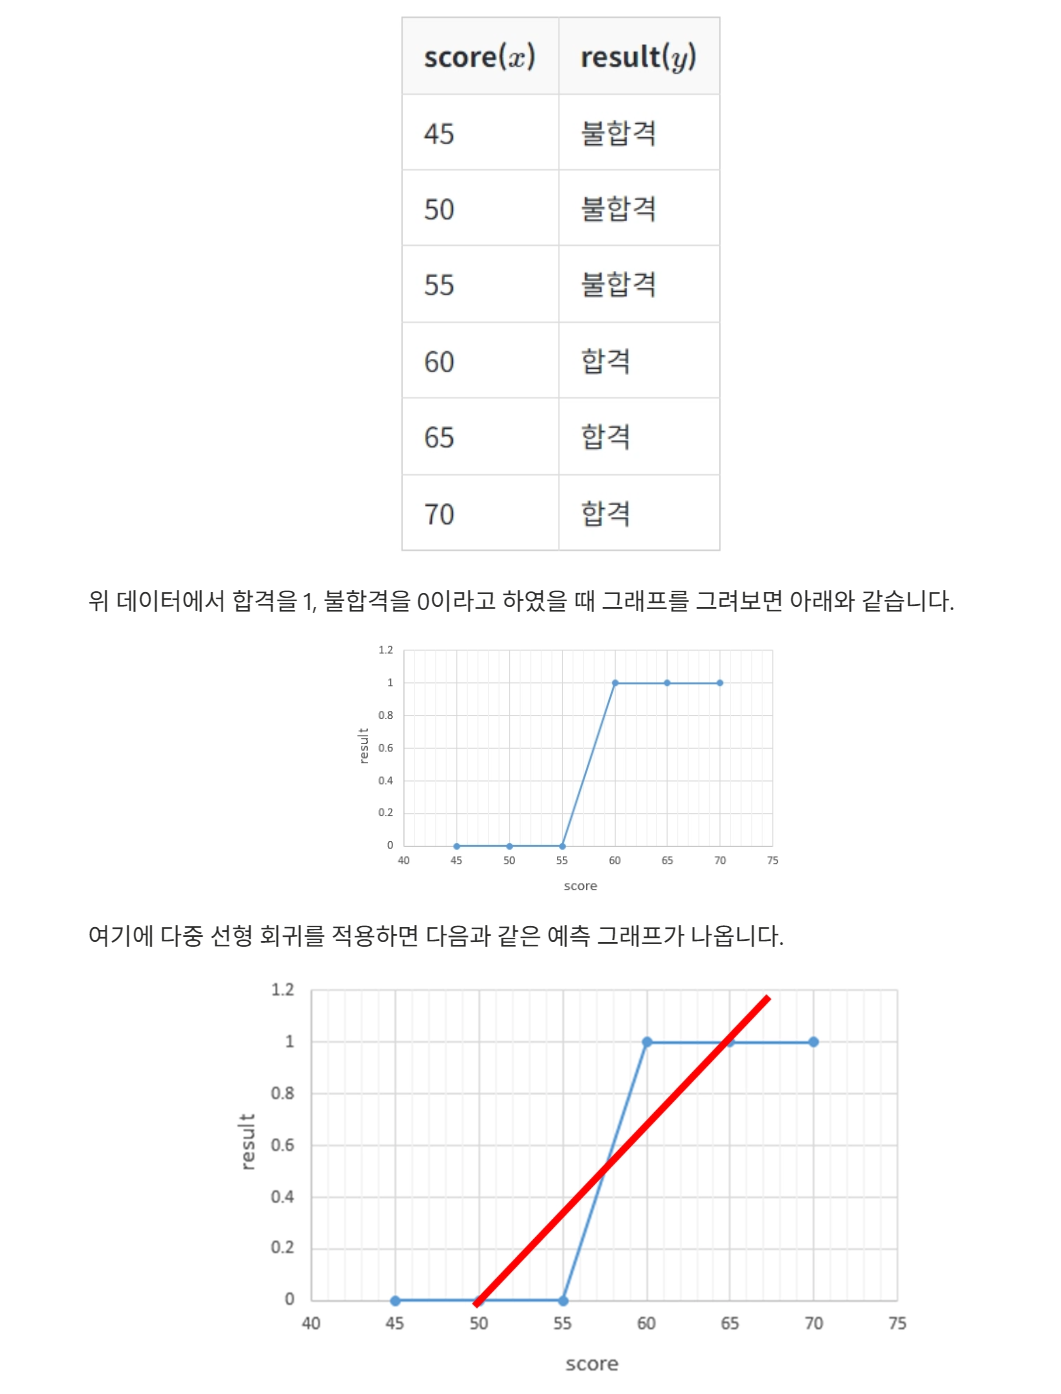  
- x와 y의 관계를 표현하려면 S자 형태로 표현가능한 함수가 필요한데, 직선은 그렇지 X
- 예측값은 0~1의 값. But 직선으로 분류하며면 값이 음의 무한대~양의 무한대가 나올 수 있다.
### 대표적인 함수 - 시그모이드
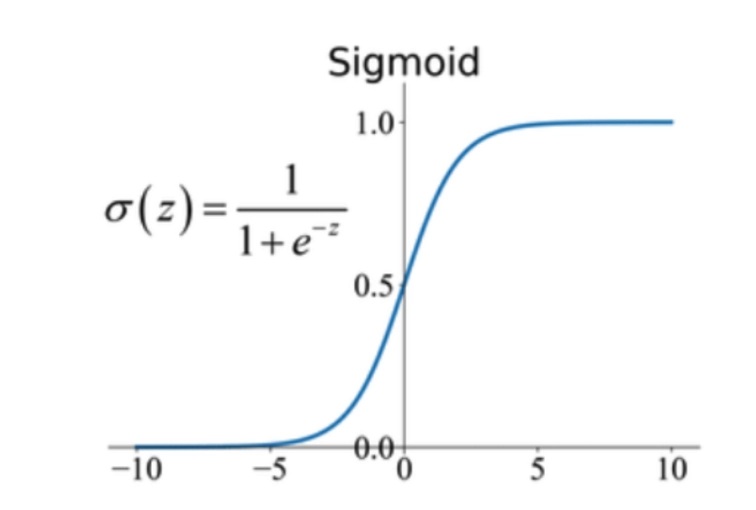  
- 입력값이 커지면 1에 수렴, 작아지면 0에 수렴
- 입력값이 $(-\infin, \infin)$일 때, 출력값은 0~1의 값 -> 출력이 0~1이면서, S자 형태로 표현!
- 특정 값을 기준으로, 기준 이상이면 1(T), 이하면 0(F)로 정해서 이진 분류
#### [시그모이드 함수의 가중치]
시그모이드 함수가 $H(x)=\frac{1}{1+e^{-(wx+b)}}=sigmoid(wx+b)=\sigma(wx+b)$일 때, 인공지능은 주어진 데이터에 적합한 가중치 $w$와 $b$를 계산해서 찾는다  
> 어떻게 찾나요?  

- **승산**: 사건 A가 일어날 확률 / 사건 A가 일어나지 않을 확률 => 발생 확률이 그렇지 않을 확률보다 몇 배 더 높은가?
- 승산 사용 시 비선형적인 결과를 선형 결과로 변환할 수 있어서 직관적 해석 가능
- $$ z=logit(p) = log(\frac{p(A)}{1-p(A)}) $$
    1. logit 함수는 **logit transform**(승산의 로그 변환)으로 정의  
    -> logit 함수 logit(p)=log( $\frac{p(A)}{1-p(A)}$)
    2. 모델에 sigmoid 함수를 적용하면 모델이 예측한 **확률**이 출력  
    -> $\frac{1}{1+e^{-(wx+b)}}=p(A)$
    3. $p(A)=\frac{1}{1+e^{-(wx+b)}}$의 양변에 **logit transform**을 적용하면  

        $logit(p)=log(\frac{p(A)}{1-p(A)})=log(\frac{\frac{1}{1+e^{-(wx+b)}}}{1-\frac{1}{1+e^{-(wx+b)}}})=wx+b$  

    => 즉, logit 함수는 로지스틱 회귀 모델이 확률(P(A))을 선형 관계로 변환하는 방법을 설명하는 함수
- 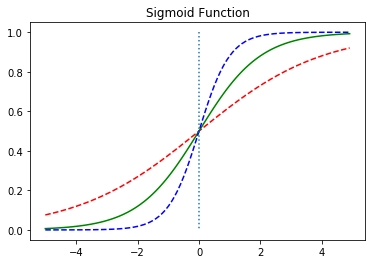  
    가중치 w가 클수록 S자 형태가 더 확연하게 드러남

- 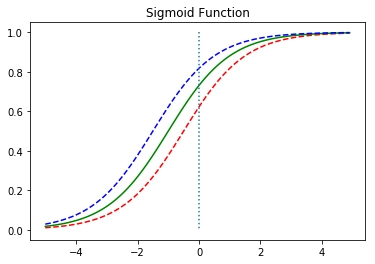  
    가중치 b가 클수록 x가 0일 때 값이 커짐

## 의사 결정 트리
최종적으로 데이터가 순수한 레이블의 집합으로 구성될 때까지 **조건에 따라 데이터 분류 반복**
### 구성요소
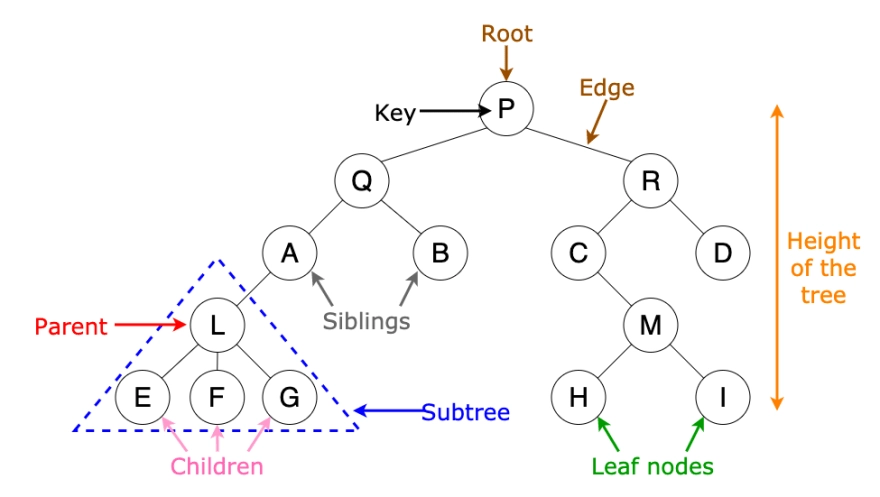  
*height = 특정 노드 ~ 리프 노드 -> 아래서부터 세는 것 / depth = 루트 노드 ~ 특정 노드 -> 위에서부터 세는 것*
### 대표적인 알고리즘 - CART
이진분할(Classification And Regression Tree) 알고리즘으로, 데이터셋을 임계값을 기준으로 두 child로 나누는 알고리즘  
> **임계값은 불순도(지니계수)가 낮아지는 방향**으로 나눈다.  
지니계수 = 통계적 분산정도를 정량화해서 표현한 값(0~1)으로, **작을수록 불순도가 낮은 것**.  
$$ Gini=1-\sum_{i=1}^n{P_i}^2,\space P_i\text{는 class i의 비율} $$
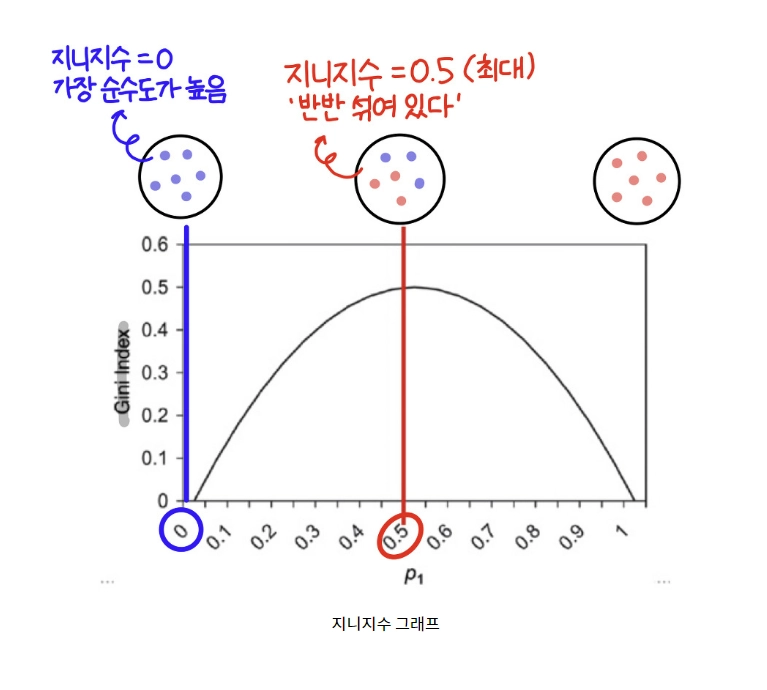  
#### [CART 알고리즘의 단계]
1. 임계값 설정: t1,...,t4의 임계값을 기준으로 데이터를 그룹으로 나눔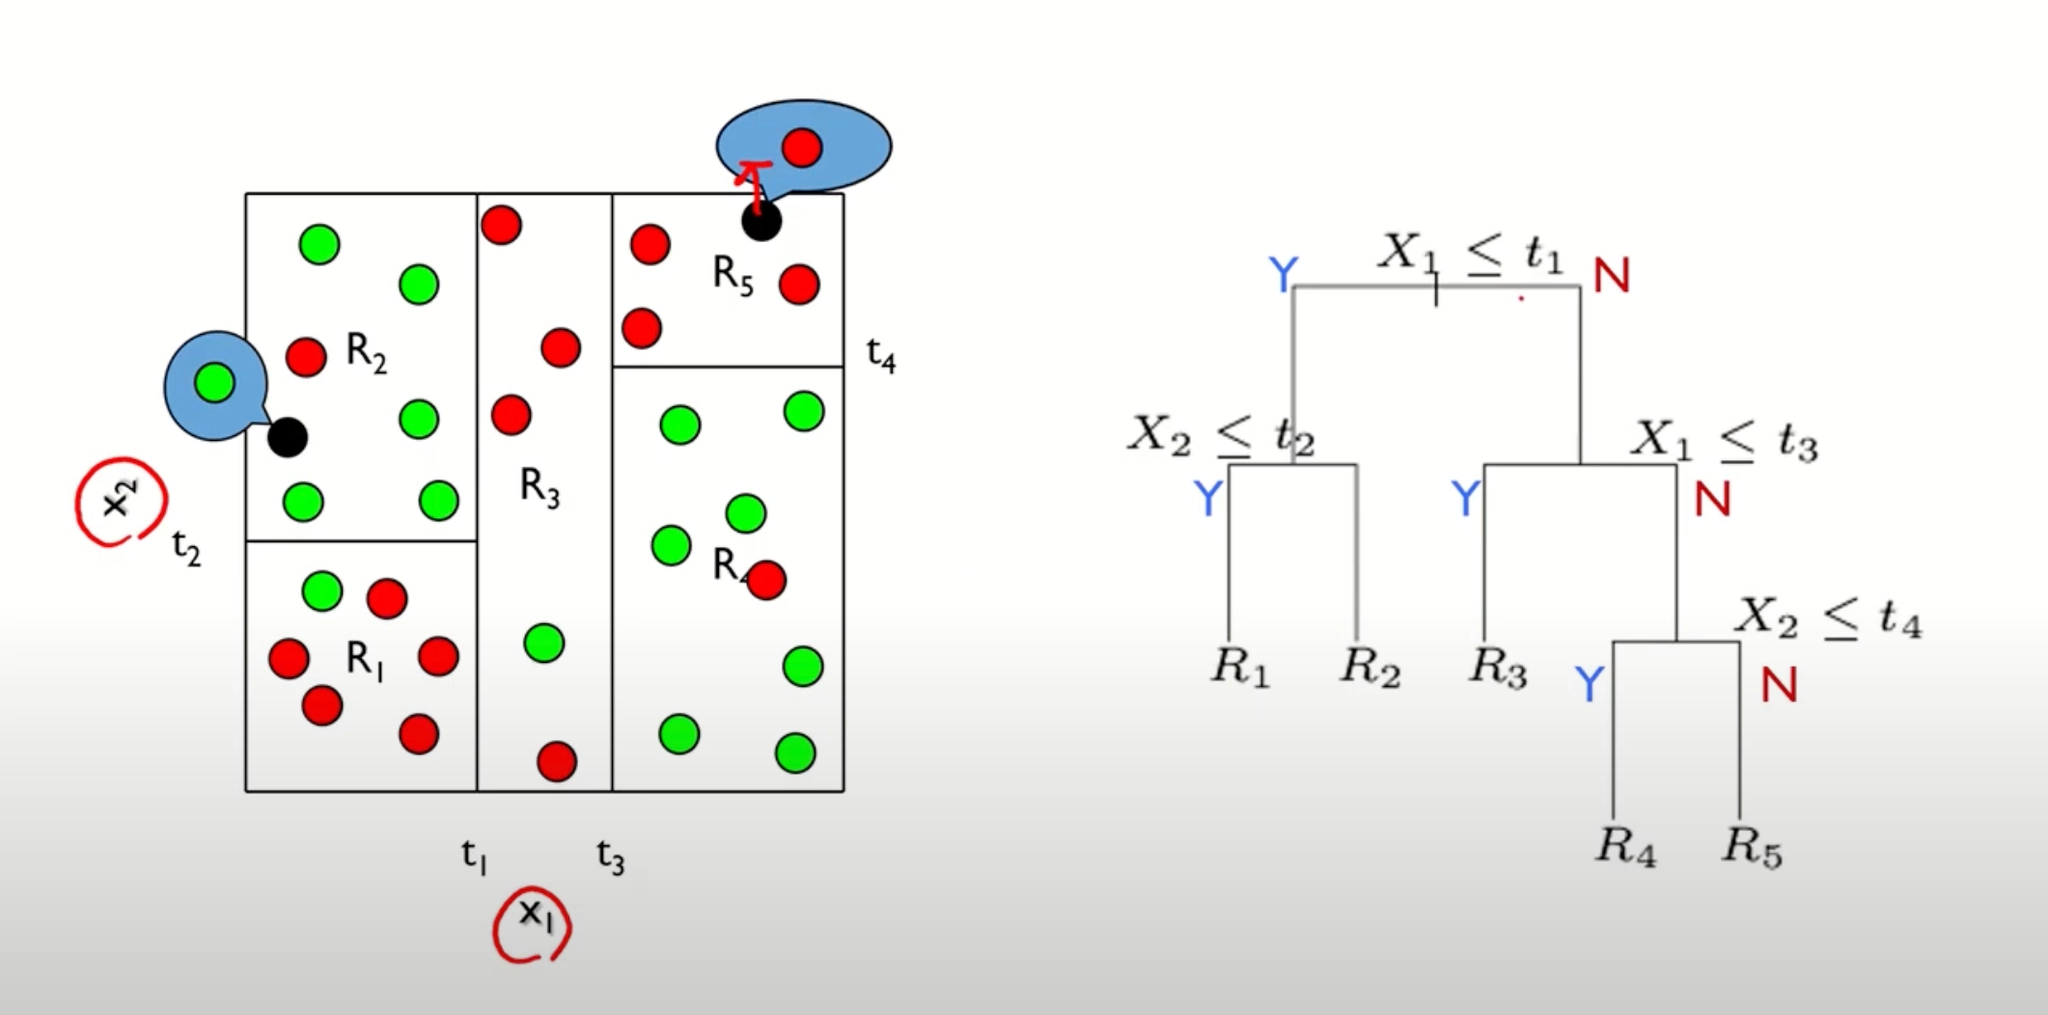
2. 불순도 감소 알고리즘: 현재 집단에 어느 정도 다른 객체들이 섞여있는지 확인하고 특정 기준으로 불순도가 낮은 쪽으로 데이터를 분류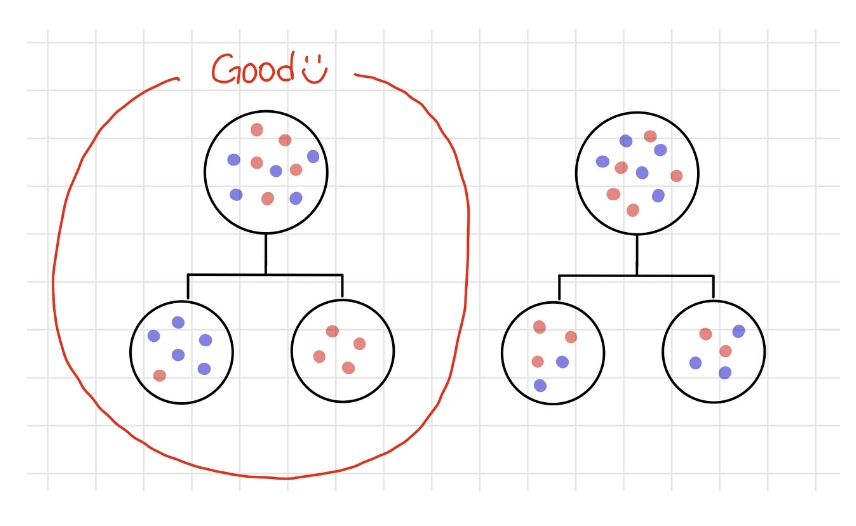
*CART 알고리즘은 greedy라 지금 당장의 불순도를 낮추는 것에만 집중함. 최고 좋은 분류를 도출하지 못할 가능성 존재*
#### [실제 학습 시 고려해야할 것들]
- 하이퍼파라미터 설정
    - min_samples_split: 분할을 위해 노드가 가져야하는 최소 데이터 수
    - min_samples_leaf: 리프 노드가 가져야할 최소 데이터 **수**
    - min_weight_fraction_leaf: 가중치가 부여된 전체 샘플 수에서의 **비율**(=min_samples_leaf)
    - max_leaf_nodes: 리프 노드의 최대 개수
    - max_features: 각 노드에서 분할에 사용할 특성의 최대 수
- 시각화: 분류가 잘 되었는지 확인
- prunning: 가지치기 = 불필요한 노드 지우기 (노드가 너무 많으면 과적합 확률 높음)

## SVM
클래스를 **분류할 수 있는 최적의 라인**을 찾아내는 알고리즘 -> 고차원 공간에서도 효과적  
> 전문용어로..  
데이터를 분리하는 **초평면**(Hyperplane) 중에서 데이터들과 **가장 거리가 먼 초평면을 선택**하여 분리하는 지도 학습 기반의 이진 선형 분류 모델  

> 초평면이란?  
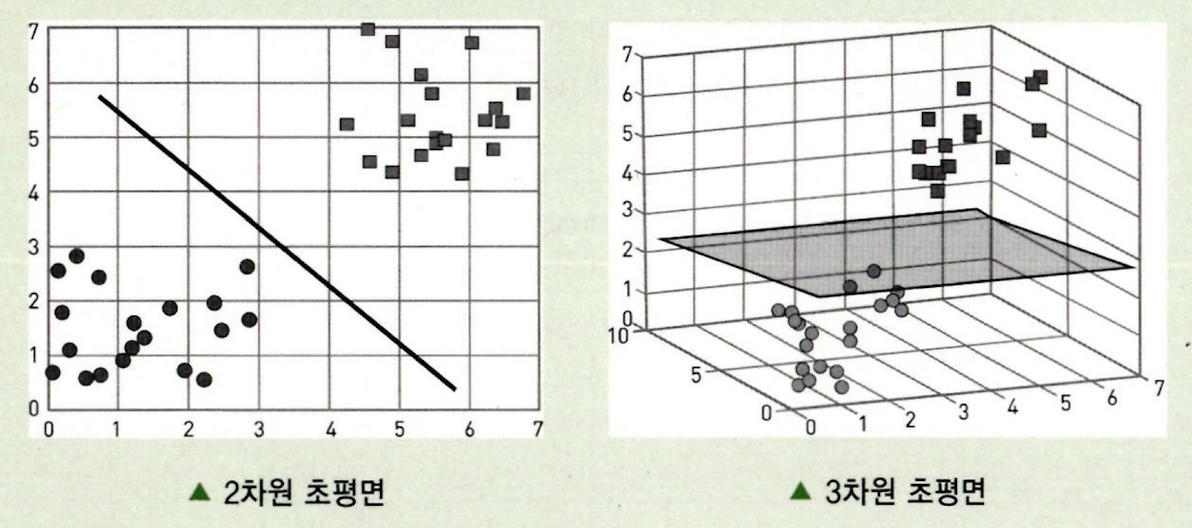  
n차원 공간을 두 부분으로 나누는 한 차원 낮은 부분 공간 -> n-1 차원  
### SVM의 구성
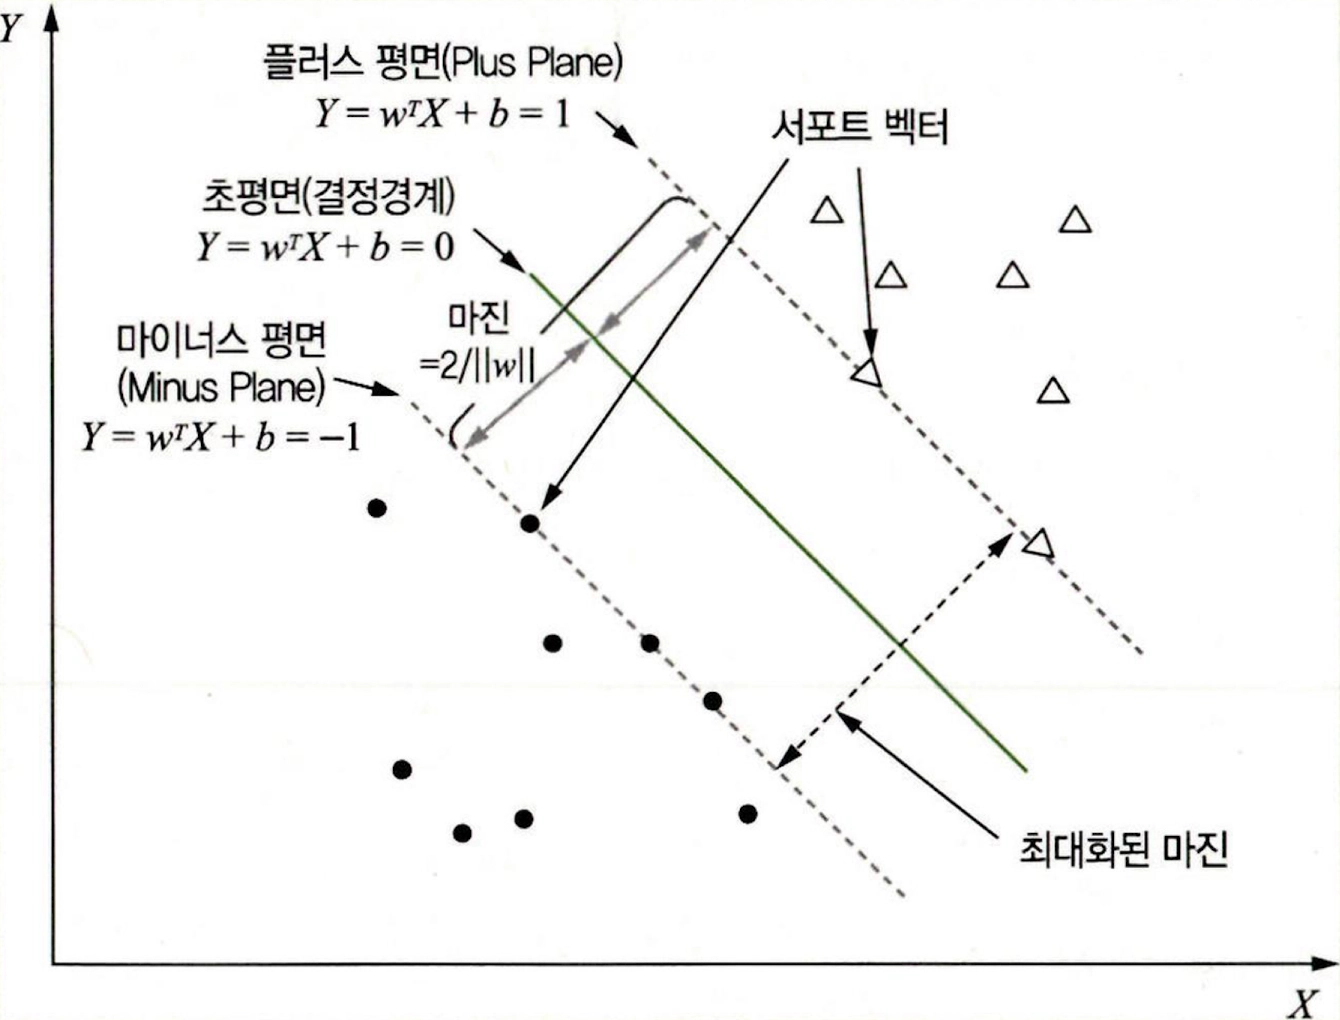  
- 서포트 벡터: 데이터 중에서 결정 경계와 가장 가까이에 있는 데이터들의 집합
- 결정경계: 데이터 분류의 기준이 되는 경계
- 마진: 결정경계~서포트벡터 거리
- 초평면: n차원 공간의 n-1차원 평면
- 슬랙 변수: 완벽한 분리가 불가능할 때 분류를 위해 허용된 오차에 대한 변수
### 최적의 선을 어떻게 찾을까?
- 마진(거리)이 가장 큰 경우를 선택함으로써 최적의 선을 찾음. 데이터로부터 멀리 떨어질수록 좋다
### SVM의 장단점
| **장점** | **단점** |
| --- | --- |
| 데이터가 적을 때 효과적(서포트 벡터만 이용하므로) | 데이터 전처리 과정 중요 |
| 연산량 최소화(새로운 벡터와 서포트 벡터 사이 거리만 계산) | 데이터가 많아질수록 속도 느림(평가 과정 많아지므로) |
| 정확성. 비선형 모델 분류 가능 |  |
| 과대 적합 가능성 낮고 노이즈 영향 적음 |  |

## KNN
데이터로부터 거리가 가까운 k개의 이웃을 설정해 이를 참조하여 분류
### 계산 순서
1. 데이터 준비: 특징벡터와 레이블로 이루어진 데이터 준비. **학습 필요 X**
2. K값 설정: 보통 홀수 개로 설정 (동점 발생 문제 방지)
    > 최적의 K는 일반적으로 학습용 데이터 개수의 제곱근으로 설정
3. 거리 계산: 새로운 데이터 주어지면 이 값과 기존 모든 데이터 간의 거리 계산 (유클리드 거리, 맨해튼 거리)
4. 가장 가까운 K개 이웃 선택: 계산된 거리가 가장 작은 K개 데이터 선택
5. 분류: K개 이웃 중 가장 많이 등장하는 클래스로 예측
### KNN의 장단점
| 장점 | 단점 |
| --- | --- |
| 범주를 나눈 기준을 알지 못해도 데이터 분류 가능 | 테스트 데이터 개수가 많으면 오래 걸림 |
| 학습 과정 필요 없음 | 학습 데이터의 양이 계산 시간에 영향을 미침 |
| 간단한 구현 | K값 결정 어려움 |
| 추가된 데이터 처리가 용이 | 수치형 데이터가 아니면 유사도를 정의하기 어려움 |
| 원본 데이터 전체를 그대로 저장 | 데이터 내 이상치가 존재하면 분류 성능에 큰 영향 |

---

# **분류 평가 지표**
## 혼동 행렬
분류 모델의 예측 결과를 **정확한 예측과 잘못된 예측으로 구분하여 나타낸 표**
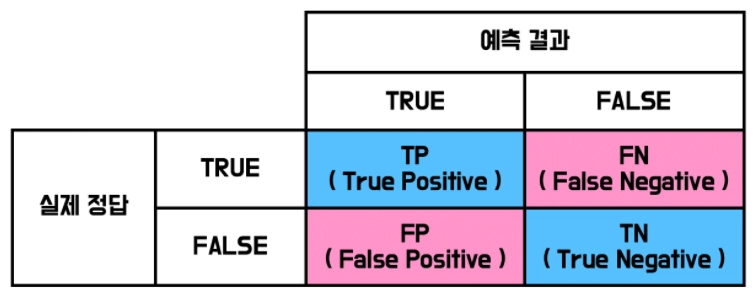  
- TP = 실제로 참인 걸 참으로 예측 -> 올바른 예측
- FP = 실제로 거짓인 걸 참으로 예측 -> 잘못된 예측
- FN = 실제로 참인 걸 거짓으로 예측 -> 잘못된 예측
- TN = 실제로 거짓인 걸 거짓으로 예측 -> 올바른 예측
### 혼동 행렬을 이용한 평가 지표
- **정확도**: 모든 가능한 예측 중 올바른 예측의 비율 -> (TP + TN) / (TP+TN+FP+FN)  
    *정답 레이블의 비율이 불균형하면 모델의 정확도 신뢰 X*
- **정밀도**: 예측을 참이라고 한 것 중 실제 참의 비율 -> TP / (TP+FP)
- **재현도**: 실제 참인 것 중 예측을 참이라고 한 것의 비율 -> TP / (TP+FN)
> 정밀도와 재현도의 관계  
- 경계값 ↑ -> positive 예측 ↓ => 정밀도 ↑, 재현도 ↓
- 경계값 ↓ -> positive 예측 ↑ => 정밀도 ↓, 재현도 ↑
- 두 그래프의 교점에서의 경계값으로 정하면 예측 오류 최소화 가능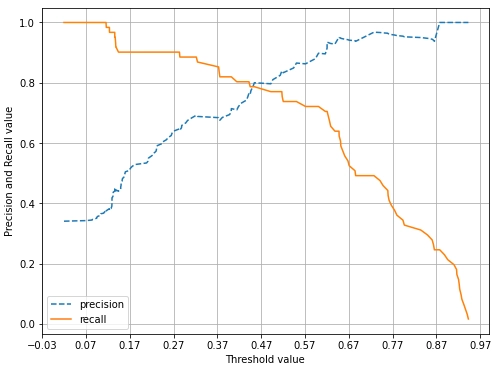
## F1 score
**정밀도와 재현율의 조화평균** -> 두 값 간의 균형을 효과적으로 평가
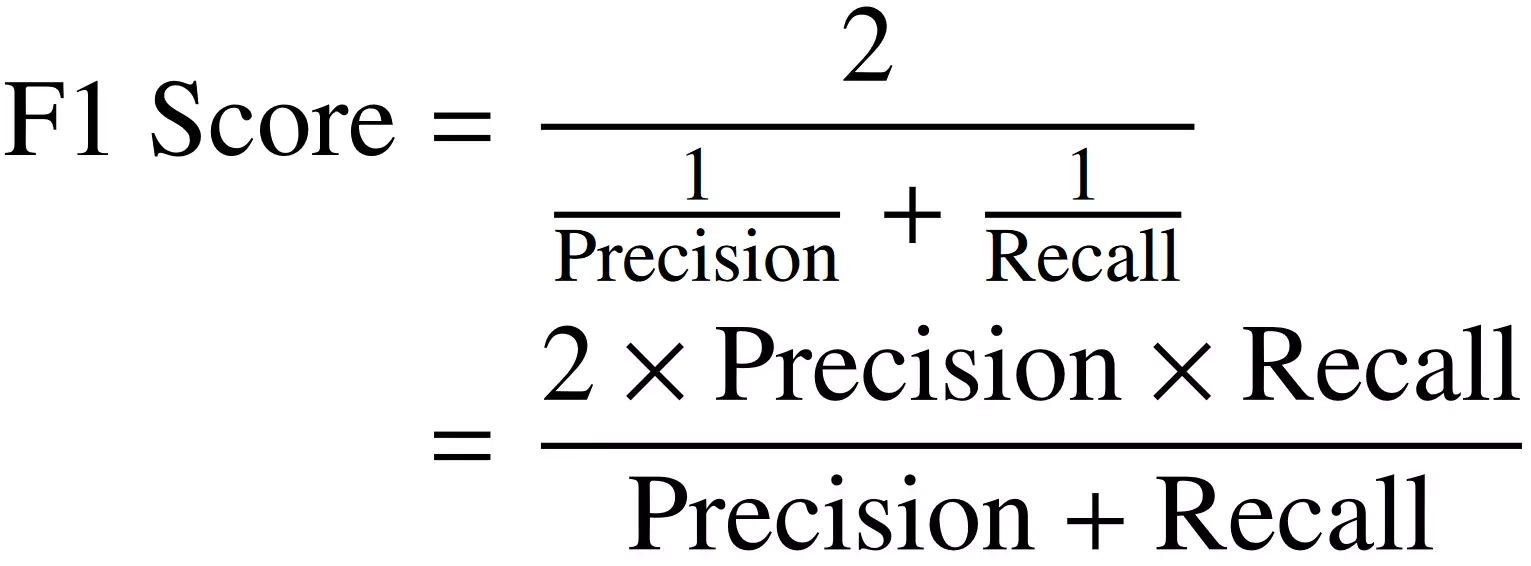
## ROC / AUC Curve
### ROC Curve
**얼마나 분류가 잘 되었는가**를 보여주는 그래프. 좌상단으로 붙어있을수록 잘 분류된 것
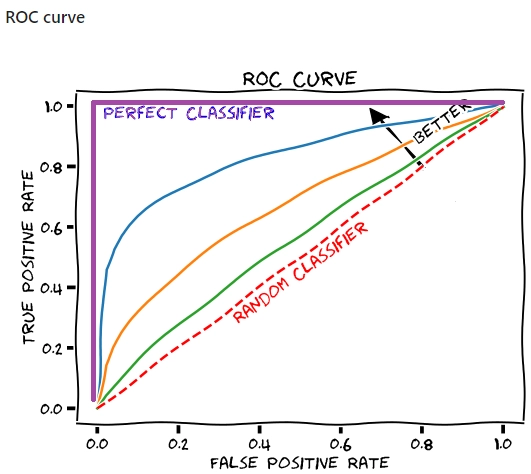  
- TPR: 실제로 참인 것들 중 참이라고 올바르게 예측한 것의 비율
- FPR: 실제로 거짓인 것들 중 참이라고 잘못 예측한 것의 비율
### AUC Curve
**ROC와 x축 사이의 면적(적분값)**. 모델의 성능을 0.5~1사이의 숫자로 나타낸 것으로, 1에 가까울수록 분류 성능이 좋다  
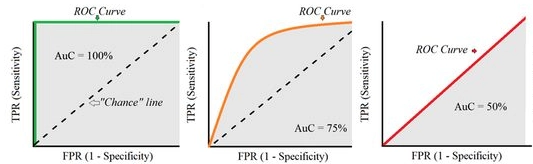  


# **하이퍼파라미터 최적화**
## 하이퍼파라미터란?
- 학습 시작 전에 사용자가 직접 설정하는 변수 -> 이를 최적화한다는 것은 모델 성능을 향상시키기 위해 적절한 값을 찾는 것
- 최적화 과정
    1. 하이퍼파라미터 탐색 범위 설정
    2. 탐색하려는 하이퍼파라미터를 인수로 받는 평가 지표 계산 함수(성능 평가 함수) 정의
    3. 1단계에서 샘플링한 하이퍼파라미터 값을 사용해 검증 데이터로 정확도 평가
    4. 위 단계를 특정 횟수 반복, 정확도 결과를 보고 하이퍼파라미터의 범위 좁힘
## 하이퍼파라미터 최적화 방법
- Grid Search: **정해진 범위에서 하이퍼파라미터를 모두 순회**하며 가장 좋은 성능을 내는 값을 찾는 기법
    - 장점: 꼼꼼히 탐색 -> 정확도 높음
    - 단점: 시간이 오래 걸림
    => 넓은 범위를 큰 스텝으로 범위를 좁힌다.
- Random Search: **정해진 범위에서 하이퍼파라미터를 무작위로 탐색**해 가장 좋은 성능을 내는 값을 찾는 기법
    - 장점: grid search보다 빠름
    - 단점: 무작위 -> 정확도 낮음
- Bayesian Optimization: **사전 정보를 바탕으로 최적 하이퍼파라미터 값을 확률적으로 추정**하며 탐색하는 기법
    - "Gausain Process"라는 통계학 기반 모델
    - 여러 개의 하이퍼 파라미터들에 대해 "Aquisition Fucntion"을 적용했을 때, "가장 큰 값"이 나올 확률이 높은 지점을 찾음
    - 방법: 초기 값 몇 개를 무작위로 실험해 어떤 파라미터 조합이 좋을지 확률 모델로 예측 -> 다음 실험 조합을 가장 좋을 거 같은 위치로 선택 -> 결과 반영 후 반복
